   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent         1.10   
1   may         mon  ...         1    999         0  nonexistent         1.10   
2   may         mon  ...         1    999         0  nonexistent         1.10   
3   may         mon  ...         1    999         0  nonexistent         1.10   
4   may         mon  ...         1    999         0  nonexistent         1.10   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

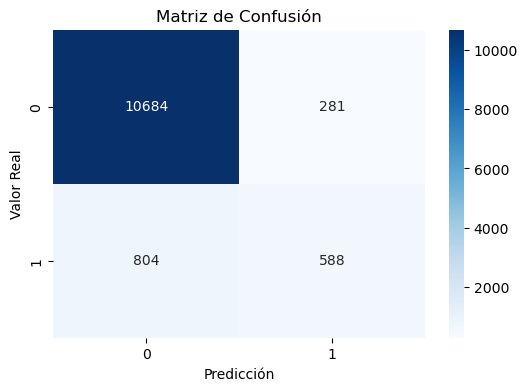

Accuracy: 0.91
Precision: 0.68
Recall: 0.42
F1 Score: 0.52


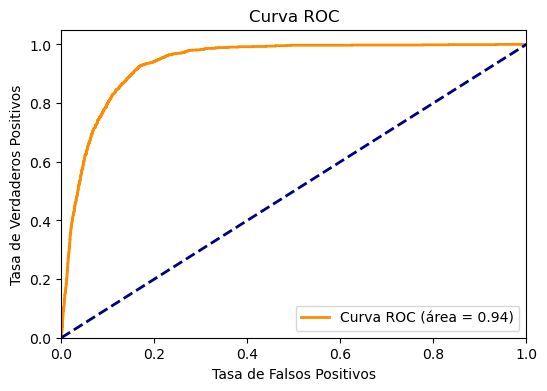

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Configura el formato de visualización
pd.options.display.float_format = '{:,.2f}'.format

# Carga el archivo
ruta_base = r"C:\Users\patri\Downloads"
ruta_archivo = os.path.join(ruta_base, "bank.csv")
df = pd.read_csv(ruta_archivo, encoding='latin1', dtype={'ITEM_CODE': str}, sep=';') # Ajustar sep=';' o ',' según el archivo

# Diagnostica los datos
print(df.head())
print(df.columns.tolist())

# Sanitiza caracteres
# Elimina caracteres especiales o 'ñ' de los nombres de las columnas
df.columns = df.columns.str.replace('ñ', 'n').str.replace('año', 'year')

# Imputa valores nulos
# Aplica imputación con la moda para categóricas y la media para numéricas
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Ingeniería de Características (Feature Engineering)
# Aplica transformación logarítmica si existe un sesgo alto (Ejemplo con una variable numérica como 'balance' o 'duration')
# df['duration'] = np.log1p(df['duration']) 

# Convierte variables categóricas a numéricas usando variables "dummy"
df = pd.get_dummies(df, drop_first=True)

# Elimina variables que tengan alta correlación y/o no sean necesarias
# Calcula la matriz de correlación
corr_matrix = df.corr().abs()
# Selecciona el triángulo superior de la matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Identifica columnas con correlación mayor a 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
# Elimina las columnas redundantes
df = df.drop(columns=to_drop)

# Define la variable objetivo (Ajustar 'y_yes' dependiendo del nombre real tras aplicar get_dummies)
X = df.drop(columns=['y_yes']) 
y = df['y_yes']

# Genera set de training y test 70:30
# Divide los datos y ajusta proporciones para evitar sesgos con stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Estandarización de variables
# Ajusta variables numéricas a media 0 y desviación 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simple modelo de regresión logística
# Ajusta el modelo con el conjunto de entrenamiento
modelo = LogisticRegression(random_state=42, max_iter=1000)
modelo.fit(X_train_scaled, y_train)

# Realiza las predicciones
y_pred = modelo.predict(X_test_scaled)
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

# Matriz de Confusión
# Revisa predicciones correctas e incorrectas
matriz_conf = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", matriz_conf)

# Grafica la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Cálculo de primeras medidas de calidad del modelo
# Calcula Accuracy, Precisión, Recall y F1 Score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:,.2f}")
print(f"Precision: {precision:,.2f}")
print(f"Recall: {recall:,.2f}")
print(f"F1 Score: {f1:,.2f}")

# Grafica el rendimiento del modelo de clasificación binaria
# Grafica la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:,.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# Confirma que los datos estén completamente limpios

### El modelo es excelente identificando a los clientes que NO van a adquirir el producto (10,684 Verdaderos Negativos frente a solo 281 Falsos Positivos).

Sin embargo, tiene dificultades para identificar a los clientes que SÍ están interesados (588 Verdaderos Positivos frente a 804 Falsos Negativos). Esto nos indica que el modelo es conservador y se le están "escapando" muchos clientes potenciales. Es un comportamiento muy común en bases de datos de marketing debido al desbalance natural (hay muchos más "No" que "Sí").

### Análisis de las Métricas de Calidad:

Accuracy (0.91): La exactitud general es muy alta (91%), pero puede ser una métrica engañosa por el desbalance de los datos. Acertar los "No" infla este número.

Precision (0.68): De todos los clientes a los que el modelo etiquetó como "interesados", el 68% realmente lo estaba. Es un número sólido que evitaría gastar recursos de campaña en clientes equivocados.

Recall (0.42): Esta es el área de mejora. El modelo solo logró capturar al 42% del total real de clientes interesados.

F1 Score (0.52): Al ser el promedio armónico entre Precision y Recall, un puntaje de 0.52 confirma que hay un desequilibrio.


In [6]:
import pandas as pd
import os
# Importa las funciones de clasificación de PyCaret
from pycaret.classification import setup, compare_models

# Configura el formato de visualización
pd.options.display.float_format = '{:,.2f}'.format

# Carga el archivo
ruta_base = r"C:\Users\patri\Downloads"
ruta_archivo = os.path.join(ruta_base, "bank.csv")
df = pd.read_csv(ruta_archivo, encoding='latin1', dtype={'ITEM_CODE': str}, sep=';')

# Limpia los nombres de las columnas por precaución
df.columns = df.columns.str.replace('ñ', 'n').str.replace('año', 'year')

# Inicializa el entorno de PyCaret (Setup)
# Aquí PyCaret hace automáticamente la imputación, el One-Hot Encoding, el escalamiento y el split 70:30
print("Iniciando configuración de PyCaret...")
experimento = setup(data=df, 
                    target='y', # Usamos la columna original, PyCaret maneja las variables categóricas
                    session_id=42, # Equivalente al random_state para reproducibilidad
                    normalize=True, # Aplica estandarización
                    normalize_method='zscore', # Equivalente a StandardScaler
                    verbose=False) # Oculta la tabla gigante de configuración inicial para mantener limpio el notebook

# Compara todos los modelos de clasificación disponibles
print("Entrenando y comparando modelos... (Esto puede tomar un par de minutos)")
mejores_modelos = compare_models()

# Imprime el modelo ganador
print("\nEl mejor modelo encontrado es:")
print(mejores_modelos)

Iniciando configuración de PyCaret...
Entrenando y comparando modelos... (Esto puede tomar un par de minutos)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9158,0.9454,0.9158,0.9089,0.9111,0.5334,0.5388,1.1470
lightgbm,Light Gradient Boosting Machine,0.9150,0.9490,0.9150,0.9096,0.9117,0.5424,0.5452,0.5120
rf,Random Forest Classifier,0.9106,0.9386,0.9106,0.9000,0.9022,0.4734,0.4866,0.6970
lr,Logistic Regression,0.9101,0.9340,0.9101,0.8991,0.9011,0.4655,0.4801,0.7610
ada,Ada Boost Classifier,0.9085,0.9371,0.9085,0.8966,0.8985,0.4484,0.4652,0.6580
lda,Linear Discriminant Analysis,0.9082,0.9327,0.9082,0.9019,0.9044,0.5036,0.5065,0.3520
ridge,Ridge Classifier,0.9062,0.9327,0.9062,0.8920,0.8915,0.3952,0.4263,0.2790
svm,SVM - Linear Kernel,0.9028,0.8925,0.9028,0.8916,0.8944,0.4348,0.4462,0.3510
et,Extra Trees Classifier,0.9017,0.9143,0.9017,0.8869,0.8897,0.3964,0.4149,0.9460
knn,K Neighbors Classifier,0.8939,0.7889,0.8939,0.8742,0.8782,0.3241,0.3466,0.6150



El mejor modelo encontrado es:
GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


1. Configurando el entorno con SMOTE activado...
2. Buscando el mejor modelo base...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9130,0.9472,0.9130,0.9092,0.9108,0.5433,0.5446,1.3710
rf,Random Forest Classifier,0.9086,0.9387,0.9086,0.8994,0.9021,0.4809,0.4888,1.8580
gbc,Gradient Boosting Classifier,0.9086,0.9412,0.9086,0.9091,0.9088,0.5451,0.5453,4.1820
ada,Ada Boost Classifier,0.9040,0.9280,0.9040,0.8992,0.9012,0.4928,0.4943,1.5910
et,Extra Trees Classifier,0.9008,0.9172,0.9008,0.8887,0.8924,0.4240,0.4336,2.3990
dummy,Dummy Classifier,0.8873,0.5000,0.8873,0.7874,0.8344,0.0000,0.0000,0.4150
dt,Decision Tree Classifier,0.8871,0.7324,0.8871,0.8905,0.8887,0.4513,0.4517,0.5550
ridge,Ridge Classifier,0.8646,0.9299,0.8646,0.9163,0.8811,0.5084,0.5436,0.4410
lda,Linear Discriminant Analysis,0.8646,0.9299,0.8646,0.9163,0.8811,0.5085,0.5438,0.6040
lr,Logistic Regression,0.8617,0.9357,0.8617,0.9217,0.8800,0.5166,0.5606,1.4130



3. Entrando a fase de Supervisión (Hyperparameter Tuning)...
Optimizando las 'perillas' del modelo para priorizar el Recall...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9157,0.9465,0.9157,0.9093,0.9115,0.5377,0.5420
1,0.9192,0.9507,0.9192,0.9149,0.9167,0.5706,0.5724
2,0.9148,0.9461,0.9148,0.9123,0.9134,0.5598,0.5603
3,0.9058,0.9401,0.9058,0.9015,0.9034,0.5057,0.5067
4,0.9152,0.9488,0.9152,0.9119,0.9134,0.5579,0.5588
Mean,0.9142,0.9464,0.9142,0.9100,0.9117,0.5463,0.5480
Std,0.0044,0.0036,0.0044,0.0046,0.0044,0.0230,0.0228


Fitting 5 folds for each of 10 candidates, totalling 50 fits

¡Modelo optimizado con éxito!

La configuración perfecta encontrada fue:
LGBMClassifier(bagging_fraction=0.6, bagging_freq=5, boosting_type='gbdt',
               class_weight=None, colsample_bytree=1.0, feature_fraction=0.8,
               importance_type='split', learning_rate=0.05, max_depth=-1,
               min_child_samples=86, min_child_weight=0.001, min_split_gain=0.9,
               n_estimators=130, n_jobs=-1, num_leaves=40, objective=None,
               random_state=42, reg_alpha=2, reg_lambda=0.001, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


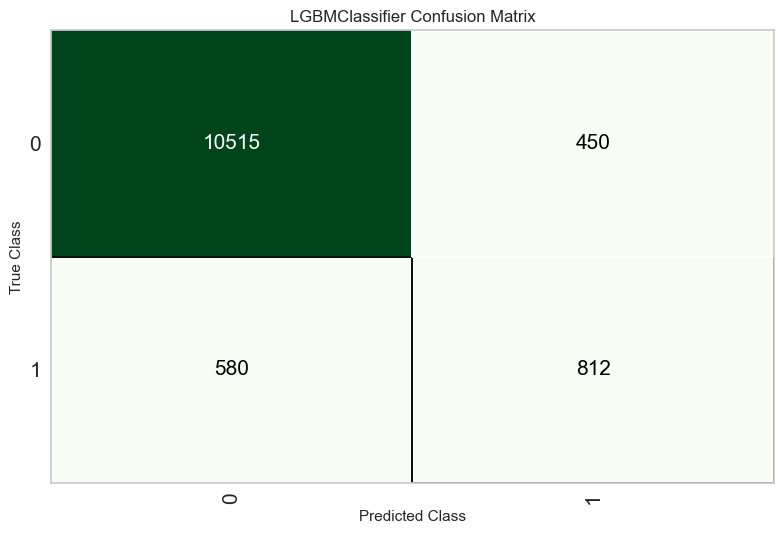

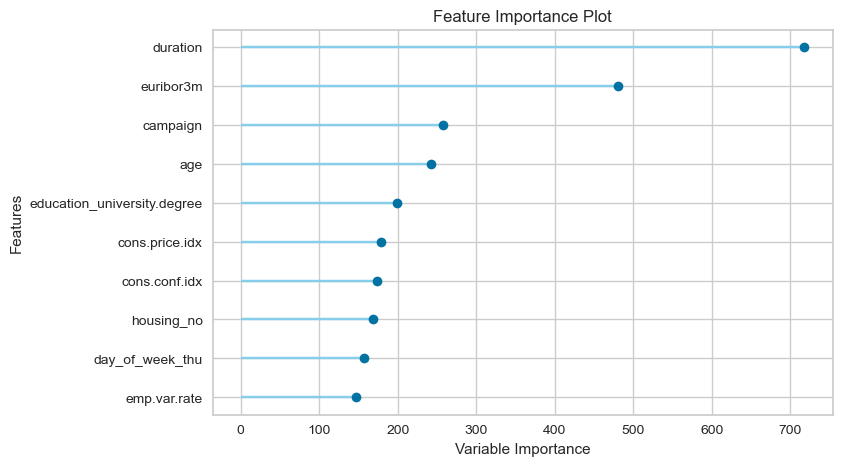

In [7]:
# Importamos las herramientas avanzadas de PyCaret
from pycaret.classification import setup, compare_models, tune_model, plot_model

print("1. Configurando el entorno con SMOTE activado...")
# EL BOTÓN MÁGICO: Agregamos fix_imbalance=True para activar SMOTE automáticamente
experimento_optimizado = setup(data=df, 
                               target='y', 
                               session_id=42, 
                               normalize=True, 
                               fix_imbalance=True, # Crea clientes sintéticos para balancear los Sí y No
                               verbose=False)

print("2. Buscando el mejor modelo base...")
# PyCaret busca al campeón (probablemente Gradient Boosting o LightGBM)
mejor_modelo = compare_models()

print("\n3. Entrando a fase de Supervisión (Hyperparameter Tuning)...")
print("Optimizando las 'perillas' del modelo para priorizar el Recall...")
# EL SUPERVISOR: tune_model ajusta la profundidad, la tasa de aprendizaje, etc.
# Le decimos explícitamente: "optimize='Recall'" porque no queremos que se nos escapen clientes.
modelo_afinado = tune_model(mejor_modelo, optimize='Recall', fold=5)

print("\n¡Modelo optimizado con éxito!")

# Imprimimos la receta final que decidió el supervisor
print("\nLa configuración perfecta encontrada fue:")
print(modelo_afinado)

# 4. Visualización del resultado
# Graficamos la nueva Matriz de Confusión para ver cómo bajaron los Falsos Negativos
plot_model(modelo_afinado, plot='confusion_matrix')

# Graficamos la importancia de las variables (Feature Importance)
# Esto te dirá qué columnas (edad, saldo, etc.) fueron las más importantes para predecir el "Sí"
plot_model(modelo_afinado, plot='feature')

In [8]:
# 1. Creamos un súper comité (Blending)
print("Creando el Súper Comité con los 3 mejores modelos...")
# Esto tomará los 3 algoritmos con mejor Accuracy de tu lista anterior y los hará votar
top_3_modelos = compare_models(n_select=3)
modelo_ensamble = blend_models(estimator_list=top_3_modelos, optimize='Recall')

# 2. Ajuste de Umbral (Threshold Tuning)
print("\nAjustando el umbral de probabilidad para el banco...")
# Le decimos a PyCaret: "Quiero un threshold que me garantice un Recall alto, 
# balanceando la ganancia del banco"
modelo_final = tune_model(modelo_ensamble, optimize='Recall', search_library='scikit-optimize')

# 3. Optimización de Threshold (Corte de Probabilidad)
# optimize_threshold busca el mejor punto de corte (ej. 0.35 en lugar de 0.50)
modelo_corte_optimo = optimize_threshold(modelo_final, optimize='Recall')

# 4. Evaluación Final
print("\n¡Mejora Finalizada! Revisemos la nueva matriz con el umbral ajustado.")
plot_model(modelo_corte_optimo, plot='confusion_matrix')

Creando el Súper Comité con los 3 mejores modelos...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9130,0.9472,0.9130,0.9092,0.9108,0.5433,0.5446,1.5770
rf,Random Forest Classifier,0.9086,0.9387,0.9086,0.8994,0.9021,0.4809,0.4888,1.8850
gbc,Gradient Boosting Classifier,0.9086,0.9412,0.9086,0.9091,0.9088,0.5451,0.5453,4.1240
ada,Ada Boost Classifier,0.9040,0.9280,0.9040,0.8992,0.9012,0.4928,0.4943,1.4600
et,Extra Trees Classifier,0.9008,0.9172,0.9008,0.8887,0.8924,0.4240,0.4336,2.5600
dummy,Dummy Classifier,0.8873,0.5000,0.8873,0.7874,0.8344,0.0000,0.0000,0.3640
dt,Decision Tree Classifier,0.8871,0.7324,0.8871,0.8905,0.8887,0.4513,0.4517,0.5310
ridge,Ridge Classifier,0.8646,0.9299,0.8646,0.9163,0.8811,0.5084,0.5436,0.4170
lda,Linear Discriminant Analysis,0.8646,0.9299,0.8646,0.9163,0.8811,0.5085,0.5438,0.6010
lr,Logistic Regression,0.8617,0.9357,0.8617,0.9217,0.8800,0.5166,0.5606,1.3390


NameError: name 'blend_models' is not defined

In [ ]:
# 0. Importamos TODAS las herramientas necesarias de PyCaret
from pycaret.classification import compare_models, tune_model, blend_models, optimize_threshold, plot_model

# 1. Creamos un súper comité (Blending)
print("Creando el Súper Comité con los 3 mejores modelos...")
# Esto tomará los 3 algoritmos con mejor Accuracy de tu lista anterior y los hará votar
top_3_modelos = compare_models(n_select=3)
modelo_ensamble = blend_models(estimator_list=top_3_modelos, optimize='Recall')

# 2. Ajuste de Umbral (Threshold Tuning)
print("\nAjustando el umbral de probabilidad para el banco...")
# Le decimos a PyCaret: "Quiero un threshold que me garantice un Recall alto, 
# balanceando la ganancia del banco"
modelo_final = tune_model(modelo_ensamble, optimize='Recall')

# 3. Optimización de Threshold (Corte de Probabilidad)
# optimize_threshold busca el mejor punto de corte (ej. 0.35 en lugar de 0.50)
modelo_corte_optimo = optimize_threshold(modelo_final, optimize='Recall')

# 4. Evaluación Final
print("\n¡Mejora Finalizada! Revisemos la nueva matriz con el umbral ajustado.")
plot_model(modelo_corte_optimo, plot='confusion_matrix')

Creando el Súper Comité con los 3 mejores modelos...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9130,0.9472,0.9130,0.9092,0.9108,0.5433,0.5446,1.4140
rf,Random Forest Classifier,0.9086,0.9387,0.9086,0.8994,0.9021,0.4809,0.4888,1.8260
gbc,Gradient Boosting Classifier,0.9086,0.9412,0.9086,0.9091,0.9088,0.5451,0.5453,4.1260
ada,Ada Boost Classifier,0.9040,0.9280,0.9040,0.8992,0.9012,0.4928,0.4943,1.4680
et,Extra Trees Classifier,0.9008,0.9172,0.9008,0.8887,0.8924,0.4240,0.4336,2.3820
dummy,Dummy Classifier,0.8873,0.5000,0.8873,0.7874,0.8344,0.0000,0.0000,0.4110
dt,Decision Tree Classifier,0.8871,0.7324,0.8871,0.8905,0.8887,0.4513,0.4517,0.5490
ridge,Ridge Classifier,0.8646,0.9299,0.8646,0.9163,0.8811,0.5084,0.5436,0.4170
lda,Linear Discriminant Analysis,0.8646,0.9299,0.8646,0.9163,0.8811,0.5085,0.5438,0.5680
lr,Logistic Regression,0.8617,0.9357,0.8617,0.9217,0.8800,0.5166,0.5606,0.6020


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9182,0.9489,0.9182,0.9126,0.9146,0.5562,0.5596
1,0.9161,0.9470,0.9161,0.9101,0.9123,0.5422,0.5458
2,0.9168,0.9487,0.9168,0.9109,0.9130,0.5460,0.5496
3,0.9220,0.9508,0.9220,0.9204,0.9211,0.6018,0.6021
4,0.9116,0.9466,0.9116,0.9076,0.9093,0.5360,0.5371
5,0.9074,0.9432,0.9074,0.9028,0.9048,0.5115,0.5128
6,0.9154,0.9462,0.9154,0.9108,0.9127,0.5504,0.5522
7,0.9005,0.9357,0.9005,0.8942,0.8969,0.4673,0.4693
8,0.9147,0.9501,0.9147,0.9097,0.9117,0.5441,0.5462



Ajustando el umbral de probabilidad para el banco...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9182,0.9492,0.9182,0.9128,0.9148,0.5575,0.5606
1,0.9161,0.9470,0.9161,0.9101,0.9123,0.5422,0.5458
2,0.9178,0.9487,0.9178,0.9122,0.9143,0.5537,0.5569
3,0.9220,0.9508,0.9220,0.9206,0.9213,0.6029,0.6031
4,0.9105,0.9468,0.9105,0.9064,0.9082,0.5299,0.5311
5,0.9070,0.9433,0.9070,0.9028,0.9046,0.5117,0.5128
6,0.9154,0.9463,0.9154,0.9110,0.9128,0.5516,0.5533
7,0.9011,0.9358,0.9011,0.8950,0.8976,0.4710,0.4730
8,0.9147,0.9503,0.9147,0.9098,0.9118,0.5454,0.5473


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
